In [45]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/4824paso/4824pasos_mlp_pollution.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 43
datosMLP = datosMLP.iloc[corte:]

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,-0.336641
2014-07-06 10:00:00,1.283232,-0.386713
2014-07-06 11:00:00,1.052817,-0.396430
2014-07-06 12:00:00,0.877262,-0.539776
2014-07-06 13:00:00,0.624902,-0.489166


In [48]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/4824paso/4824pasos_lstm_pollution.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 43
datosLSTM = datosLSTM.iloc[corte:]

# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,-0.035553
2014-07-06 10:00:00,1.283232,-0.071128
2014-07-06 11:00:00,1.052817,-0.080170
2014-07-06 12:00:00,0.877262,-0.142746
2014-07-06 13:00:00,0.624902,-0.206448


In [49]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/4824paso/4824pasos_gru_pollution.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 43
datosGRU = datosGRU.iloc[corte:]

# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,-0.124060
2014-07-06 10:00:00,1.283232,-0.152511
2014-07-06 11:00:00,1.052817,-0.174189
2014-07-06 12:00:00,0.877262,-0.197189
2014-07-06 13:00:00,0.624902,-0.228351


In [50]:
datosCross= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/4824paso/crossformerPollution.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,-0.438089
2014-07-06 10:00:00,1.283232,-0.483792
2014-07-06 11:00:00,1.052817,-0.498070
2014-07-06 12:00:00,0.877262,-0.526446
2014-07-06 13:00:00,0.624902,-0.563600


In [51]:
datosI= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/4824paso/itransformerPollution.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)
datosI.index = datosCross.index
datosI.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,-0.114161
2014-07-06 10:00:00,1.283232,-0.202381
2014-07-06 11:00:00,1.052817,-0.114863
2014-07-06 12:00:00,0.877262,-0.340186
2014-07-06 13:00:00,0.624902,-0.339569


In [52]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/4824paso/tftPollution.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])

corte = 4468 - 4337 - 21
datosTFT = datosTFT.iloc[corte:]

# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,-0.413444
2014-07-06 10:00:00,1.283232,-0.413641
2014-07-06 11:00:00,1.052817,-0.413776
2014-07-06 12:00:00,0.877262,-0.413876
2014-07-06 13:00:00,0.624902,-0.413937


## MLP ##

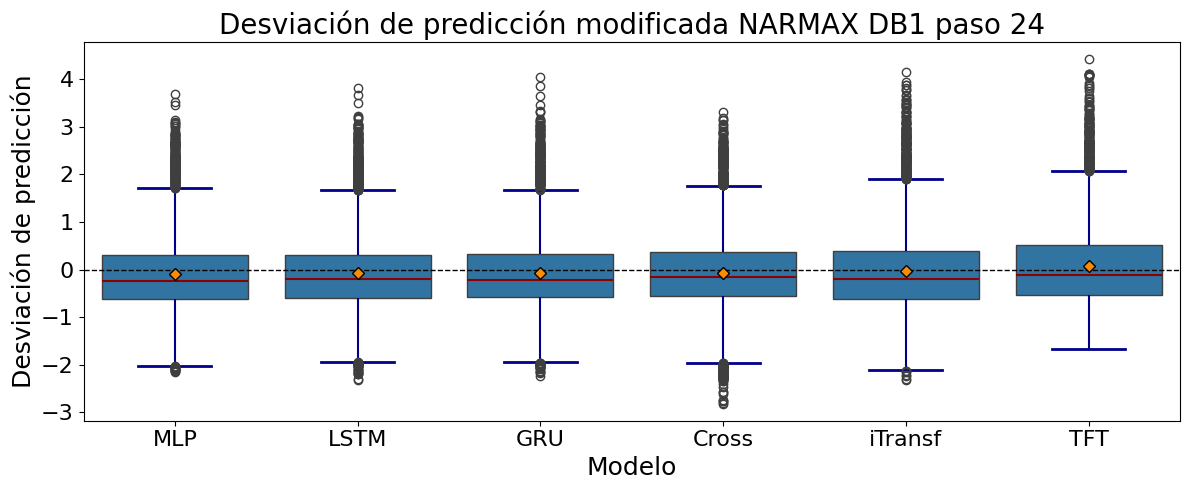

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función para calcular las desviaciones
def calcular_desviacion(df, nombre_modelo):
    desviacion = df['Originales'] - df['Predichos']
    return pd.DataFrame({'Desviacion': desviacion, 'Modelo': nombre_modelo})

# Lista de modelos y sus datos
dataframes = [datosMLP, datosLSTM, datosGRU, datosCross, datosI, datosTFT]
nombres_modelos = ['MLP', 'LSTM', 'GRU', 'Cross', 'iTransf', 'TFT']

# Calcular todas las desviaciones
todas_las_desviaciones = [calcular_desviacion(df, nombre_modelo) for df, nombre_modelo in zip(dataframes, nombres_modelos)]

# Combinar todos los DataFrames en uno solo
df_grafico = pd.concat(todas_las_desviaciones, ignore_index=True)

# Crear los gráficos de caja
plt.figure(figsize=(12, 5))
sns.boxplot(x='Modelo', y='Desviacion', data=df_grafico, showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"darkorange", "markeredgecolor":"black"},
            medianprops={"color": "darkred", "linewidth": 1.5},
            whiskerprops=dict(color="darkblue", linewidth=1.5),
            capprops=dict(color="darkblue", linewidth=2))

# Línea horizontal en y=0
plt.axhline(0, linestyle= "--",color='black', linewidth=1.0)


plt.title('Desviación de predicción modificada NARMAX DB1 paso 24', fontsize=20)
plt.ylabel('Desviación de predicción', fontsize=18)
plt.xlabel('Modelo', fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

#Por la naturaleza del gráfico, no se incluye leyenda


plt.tight_layout()
plt.show()


# Graficos Q-Q

In [54]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])

final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-07-06 09:00:00,1.630846,1.329757,1.418264,1.732293,1.408366,1.707648
2014-07-06 10:00:00,1.669945,1.354360,1.435743,1.767024,1.485613,1.696873
2014-07-06 11:00:00,1.449247,1.132986,1.227006,1.550886,1.167680,1.466592
2014-07-06 12:00:00,1.417037,1.020008,1.074451,1.403708,1.217448,1.291137
2014-07-06 13:00:00,1.114068,0.831350,0.853252,1.188502,0.964471,1.038839


In [55]:
finalTotal = final.isna().sum()
print(finalTotal)
final = final.dropna()

MLP             0
LSTM            0
GRU             0
Crossformer     0
iTransformer    0
TFT             0
dtype: int64


In [56]:
final = final.sample(frac=0.10, random_state=42)
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-08-26 05:00:00,-0.324736,-0.366830,-0.409966,-0.294649,-0.449688,-0.430210
2014-10-31 23:00:00,0.113557,0.273725,0.230465,0.345416,0.263833,0.405697
2014-11-13 01:00:00,-0.573662,-0.323035,-0.395134,-0.709682,-0.584407,-0.562833
2014-12-14 02:00:00,0.917223,0.997124,1.034368,1.244850,1.074237,1.322211
2014-12-06 23:00:00,-0.661596,-0.458102,-0.404852,-0.996978,-0.130727,0.040237


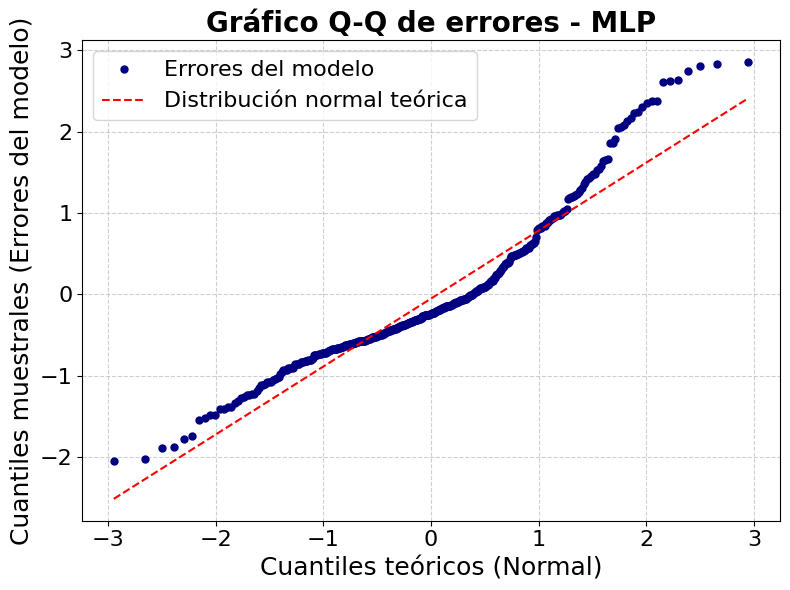

In [57]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["MLP"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - MLP", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


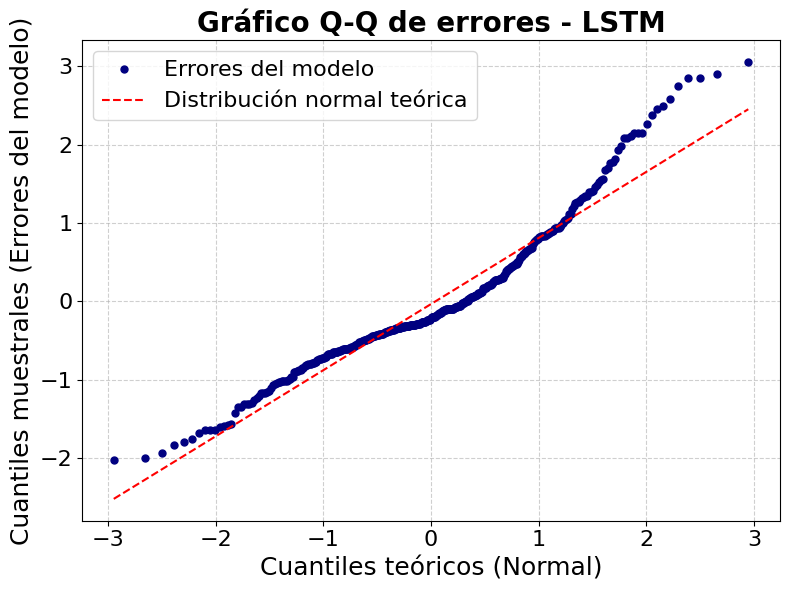

In [58]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["LSTM"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - LSTM", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


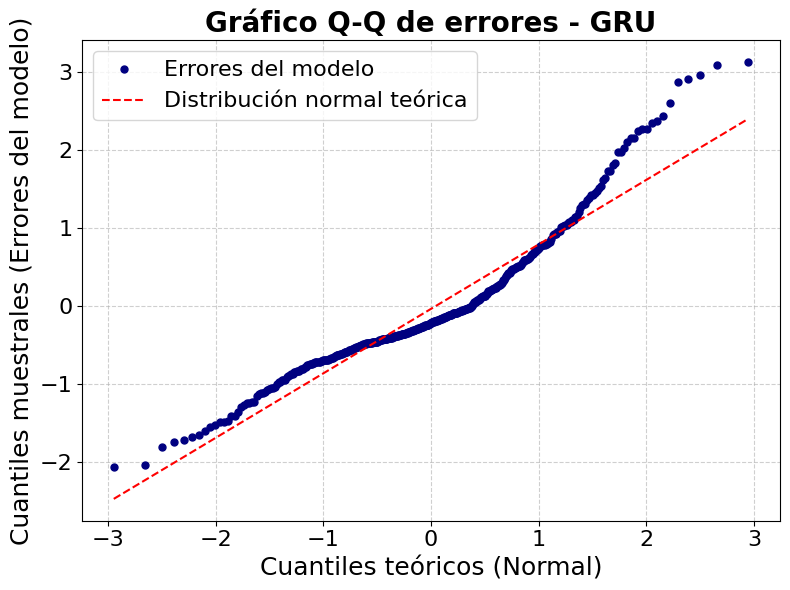

In [59]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["GRU"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - GRU", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


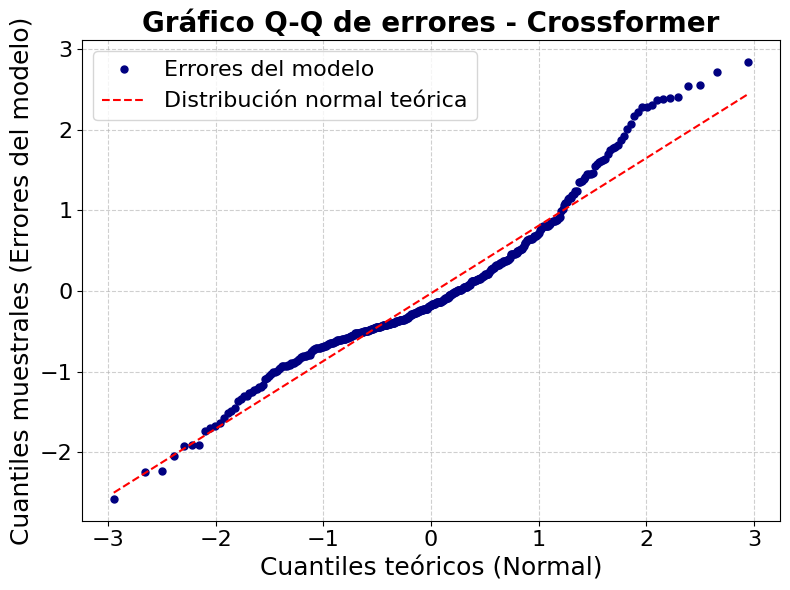

In [60]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["Crossformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - Crossformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


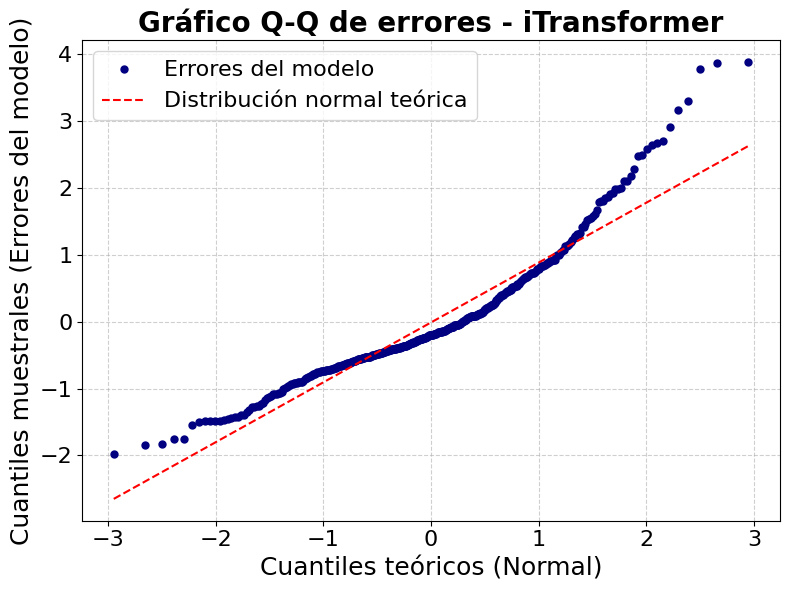

In [61]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["iTransformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - iTransformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


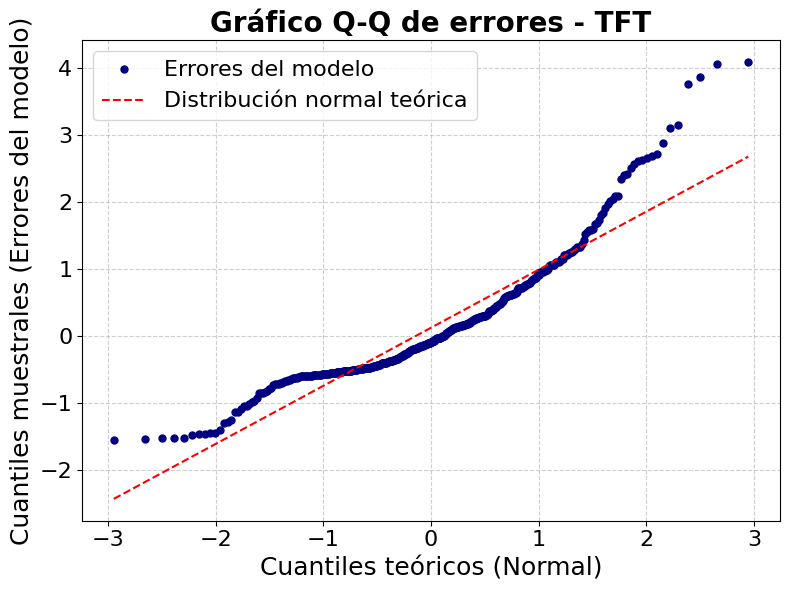

In [62]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["TFT"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - TFT", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


# Predicción

In [63]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

meses = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}
def formatear_mes(x, pos):
    fecha = mdates.num2date(x)
    return meses.get(fecha.month, '')

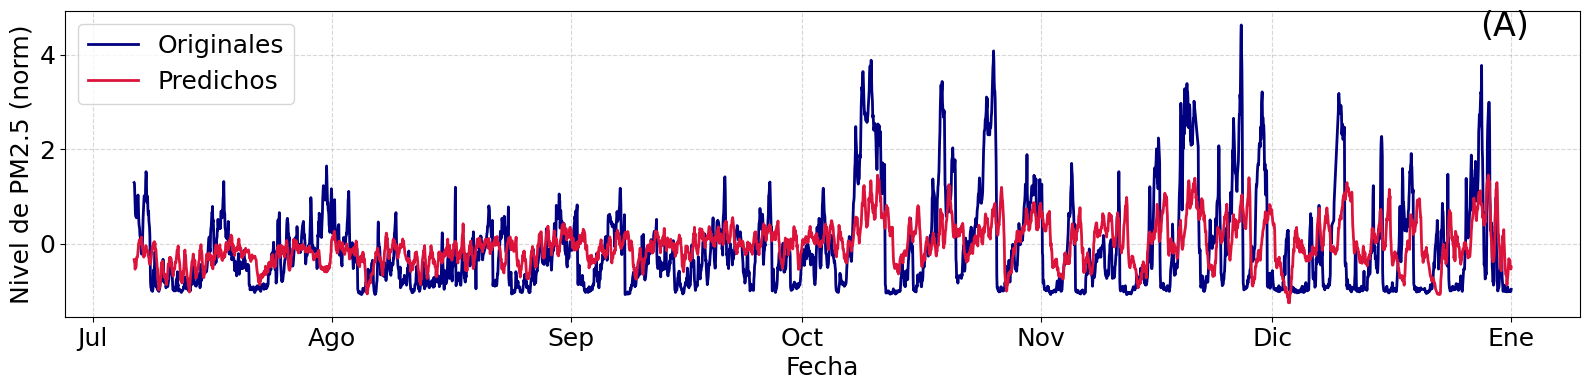

In [64]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosMLP

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(A)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


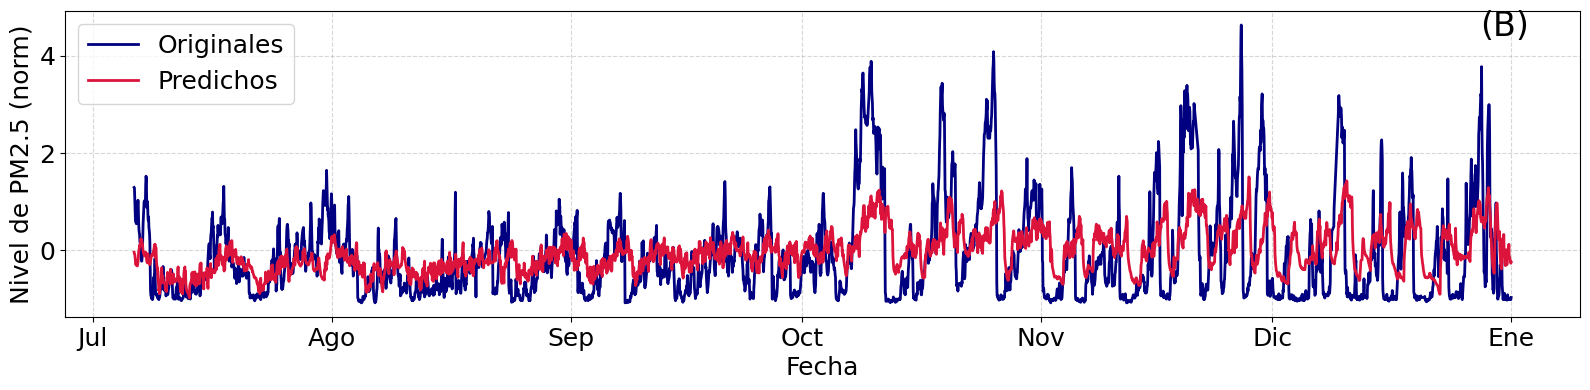

In [65]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosLSTM

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(B)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


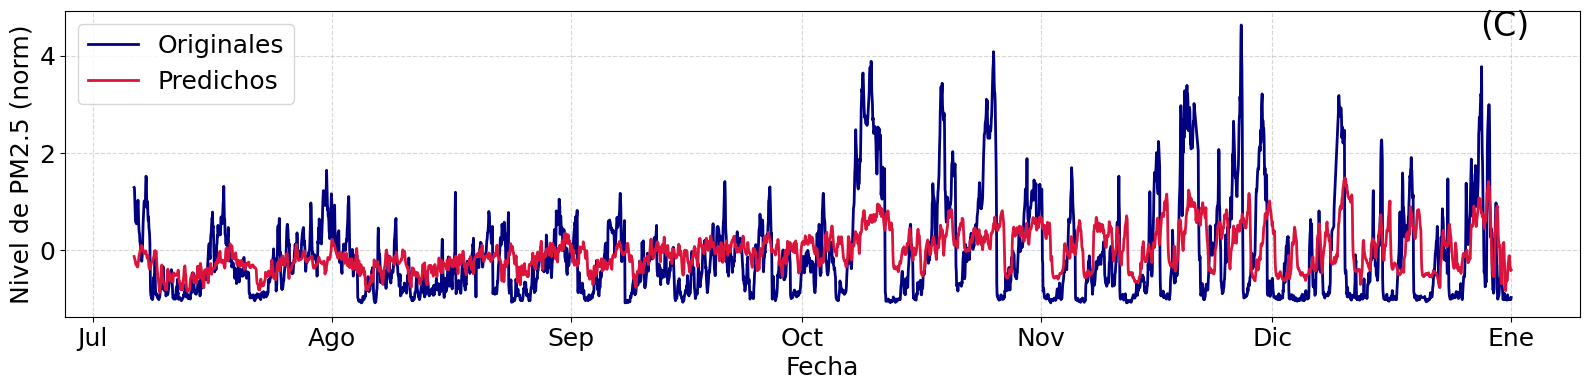

In [66]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosGRU

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(C)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


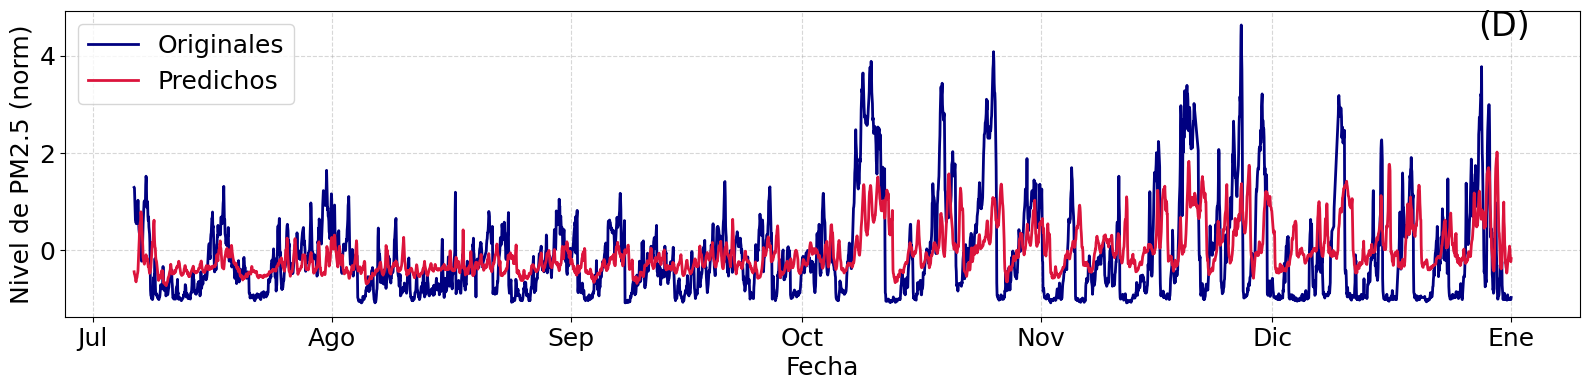

In [67]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosCross

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(D)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


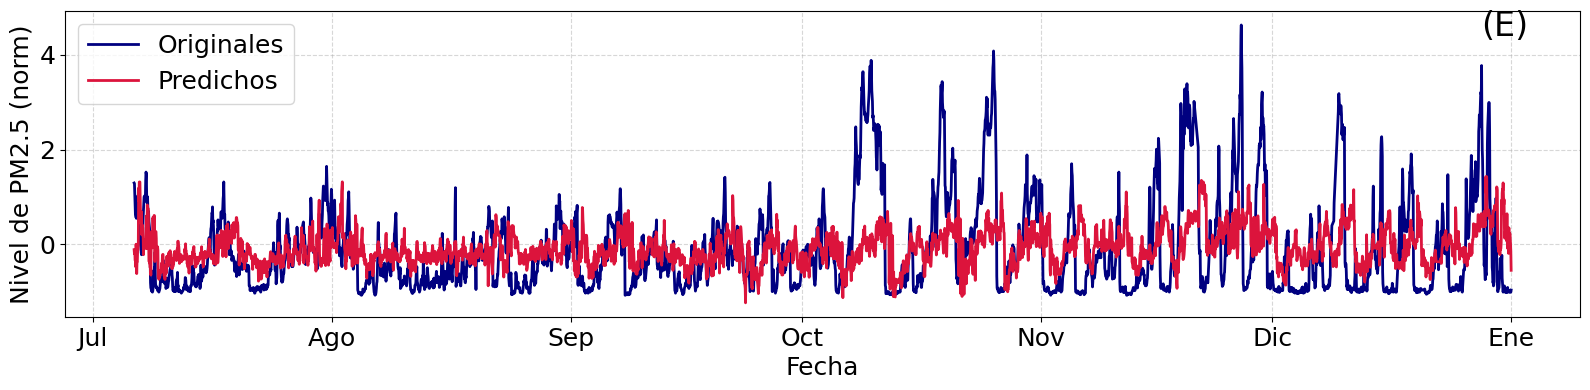

In [68]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosI

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(E)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


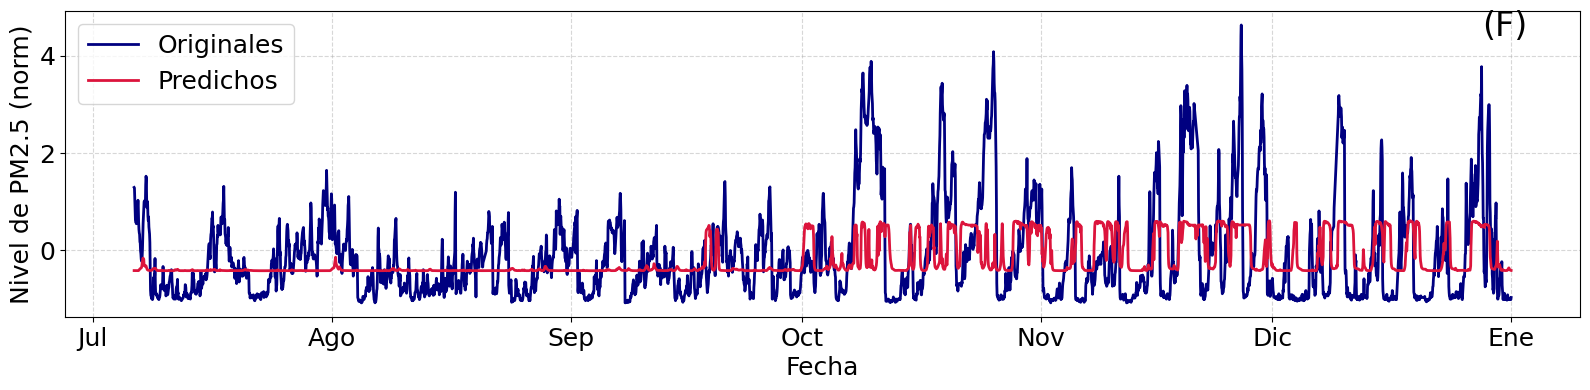

In [69]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosTFT

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(F)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


# Métricas

In [70]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [71]:
#MLP
df = datosMLP

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7893863869204027
RMSE: 0.8884741903513026
MAE: 0.6788010304465345
SMAPE: 1.3082761256059958
IA: 0.36472262262638355


In [72]:
#LSTM
df = datosLSTM

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7843675748613862
RMSE: 0.8856452872687723
MAE: 0.6651488383419754
SMAPE: 1.2633797760268604
IA: 0.37657024101119974


In [73]:
#GRU
df = datosGRU

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.775513422631922
RMSE: 0.8806323992631216
MAE: 0.6621805061271954
SMAPE: 1.2678418583314508
IA: 0.3746217470930875


In [74]:
#CROSS
df = datosCross

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.8001931969954735
RMSE: 0.894535184884012
MAE: 0.6713012997325192
SMAPE: 1.2203100595593208
IA: 0.3732625474243221


In [75]:
#iTransf
df = datosI

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.9023988728902008
RMSE: 0.9499467737142965
MAE: 0.707967366098788
SMAPE: 1.3154565499493893
IA: 0.3065918000477137


In [76]:
#TFT
df = datosTFT

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.8771827343707507
RMSE: 0.9365803405852328
MAE: 0.6876699516405202
SMAPE: 1.1411136301484366
IA: 0.36439598541343987


# Pruebas de significación

In [77]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [78]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print("MLP48:", p)
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print("LSTM48:", p)
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print("GRU48:", p)
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print("Cross48:", p)
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print("iTransf48:", p)
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print("TFT48:", p)


MLP48: 8.3533649778716e-10
LSTM48: 2.6508225218962003e-07
GRU48: 4.444437675061446e-09
Cross48: 1.1673406317877327e-05
iTransf48: 1.000746926951507e-06
TFT48: 1.0035421767793824e-10


In [79]:
datosMLPO = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/24pasos_mlp_pollution.csv')

datosMLPO['date'] = pd.to_datetime(datosMLPO['Unnamed: 0'])
datosMLPO = datosMLPO.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosMLPO = datosMLPO.iloc[corte:]

# Se establece la columna date como index
datosMLPO.set_index('date', inplace=True)

datosMLPO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.147692
2014-07-04 22:00:00,0.559069,0.308571
2014-07-04 23:00:00,0.613930,0.351226
2014-07-05 00:00:00,0.745596,0.449565
2014-07-05 01:00:00,0.789484,0.368602


In [80]:
datosLSTMO = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/24pasos_lstm_pollution.csv')

datosLSTMO['date'] = pd.to_datetime(datosLSTMO['Unnamed: 0'])
datosLSTMO = datosLSTMO.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosLSTMO = datosLSTMO.iloc[corte:]

# Se establece la columna date como index
datosLSTMO.set_index('date', inplace=True)

datosLSTMO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.128463
2014-07-04 22:00:00,0.559069,0.241268
2014-07-04 23:00:00,0.613930,0.314786
2014-07-05 00:00:00,0.745596,0.348594
2014-07-05 01:00:00,0.789484,0.179847


In [81]:
datosGRUO= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/24pasos_gru_pollution.csv')

datosGRUO['date'] = pd.to_datetime(datosGRUO['Unnamed: 0'])
datosGRUO = datosGRUO.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosGRUO = datosGRUO.iloc[corte:]

# Se establece la columna date como index
datosGRUO.set_index('date', inplace=True)

datosGRUO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,-0.159769
2014-07-04 22:00:00,0.559069,-0.044846
2014-07-04 23:00:00,0.613930,0.036686
2014-07-05 00:00:00,0.745596,0.102364
2014-07-05 01:00:00,0.789484,0.126591


In [82]:
datosCrossO= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/crossformerPollution.csv')

datosCrossO['date'] = pd.to_datetime(datosCrossO['Unnamed: 0'])
datosCrossO = datosCrossO.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCrossO.set_index('date', inplace=True)

datosCrossO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.009063
2014-07-04 22:00:00,0.559069,0.219173
2014-07-04 23:00:00,0.613930,0.344451
2014-07-05 00:00:00,0.745596,0.561541
2014-07-05 01:00:00,0.789484,0.531499


In [83]:
datosIO= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/itransformerPollution.csv')

datosIO['date'] = pd.to_datetime(datosIO['Unnamed: 0'])
datosIO = datosIO.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosIO.set_index('date', inplace=True)
datosIO.index = datosCrossO.index
datosIO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.855610
2014-07-04 22:00:00,0.559069,0.856116
2014-07-04 23:00:00,0.613930,0.992877
2014-07-05 00:00:00,0.745596,0.993342
2014-07-05 01:00:00,0.789484,0.813371


In [84]:
datosTFTO= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/pollution/tftPollution.csv')

datosTFTO['date'] = pd.to_datetime(datosTFTO['Unnamed: 0'])
datosTFTO = datosTFTO.drop(columns=['Unnamed: 0'])

corte = 4468 - 4337 - 21
datosTFTO = datosTFTO.iloc[corte:]

# Se establece la columna date como index
datosTFTO.set_index('date', inplace=True)

datosTFTO.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,-0.053353
2014-07-04 22:00:00,0.559069,0.026601
2014-07-04 23:00:00,0.613930,0.083297
2014-07-05 00:00:00,0.745596,0.118325
2014-07-05 01:00:00,0.789484,-0.041917


In [85]:
rMLPO = pd.DataFrame(datosMLPO['Originales'] - datosMLPO['Predichos'], columns=['MLPO'])
rLSTMO = pd.DataFrame(datosLSTMO['Originales'] - datosLSTMO['Predichos'], columns=['LSTMO'])
rGRUO = pd.DataFrame(datosGRUO['Originales'] - datosGRUO['Predichos'], columns=['GRUO'])
rCrossO = pd.DataFrame(datosCrossO['Originales'] - datosCrossO['Predichos'], columns=['CrossformerO'])
rIO = pd.DataFrame(datosIO['Originales'] - datosIO['Predichos'], columns=['iTransformerO'])
rTFTO = pd.DataFrame(datosTFTO['Originales'] - datosTFTO['Predichos'], columns=['TFTO'])

final2 = final.join(rMLPO, how='outer').join(rLSTMO, how='outer').join(rGRUO, how='outer').join(rCrossO, how='outer').join(rIO, how='outer').join(rTFTO, how='outer')
final2.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT,MLPO,LSTMO,GRUO,CrossformerO,iTransformerO,TFTO
date,,,,,,,,,,,,
2014-07-04 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.641793,0.661022,0.949253,0.780421,-0.066125,0.842837
2014-07-04 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.250498,0.317800,0.603915,0.339895,-0.297047,0.532467
2014-07-04 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.262703,0.299143,0.577243,0.269479,-0.378947,0.530633
2014-07-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.296031,0.397001,0.643232,0.184054,-0.247747,0.627271
2014-07-05 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.420883,0.609637,0.662893,0.257985,-0.023887,0.831402


In [86]:
finalTotal2 = final2.isna().sum()
print(finalTotal2)
final2 = final2.dropna()
final2.head()

MLP              3894
LSTM             3894
GRU              3894
Crossformer      3894
iTransformer     3894
TFT              3894
MLPO                0
LSTMO               0
GRUO                0
CrossformerO        0
iTransformerO       0
TFTO                0
dtype: int64


,MLP,LSTM,GRU,Crossformer,iTransformer,TFT,MLPO,LSTMO,GRUO,CrossformerO,iTransformerO,TFTO
date,,,,,,,,,,,,
2014-07-06 17:00:00,0.921549,0.934207,0.917322,1.207037,1.254387,1.050016,0.970456,0.953662,0.956673,1.052705,0.742517,0.905779
2014-07-06 23:00:00,0.570229,0.608336,0.742343,0.677088,-0.604518,0.993294,0.493619,0.620379,0.766617,0.449599,0.326919,0.847021
2014-07-07 02:00:00,0.250035,0.218472,0.384164,-0.176120,-0.987119,0.713430,0.102690,0.225847,0.419324,-0.141235,-0.539987,0.479944
2014-07-07 08:00:00,-0.361527,-0.449075,-0.318551,-0.915541,-0.906975,0.127278,-0.495800,-0.444043,-0.304820,-0.576842,-1.076559,-0.615072
2014-07-07 18:00:00,1.255615,1.113704,1.069404,1.242585,0.914108,1.323744,1.100030,1.139866,1.132286,1.177580,1.245084,0.891115


In [87]:
final2 = final2.loc[final.index]
final2.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT,MLPO,LSTMO,GRUO,CrossformerO,iTransformerO,TFTO
date,,,,,,,,,,,,
2014-08-26 05:00:00,-0.324736,-0.366830,-0.409966,-0.294649,-0.449688,-0.430210,-0.423487,-0.383269,-0.419727,-0.324629,-0.512674,-0.386704
2014-10-31 23:00:00,0.113557,0.273725,0.230465,0.345416,0.263833,0.405697,0.269105,0.292104,0.197661,0.344848,0.551861,1.165135
2014-11-13 01:00:00,-0.573662,-0.323035,-0.395134,-0.709682,-0.584407,-0.562833,-0.317559,-0.340632,-0.481320,-0.501279,-0.598405,-0.473428
2014-12-14 02:00:00,0.917223,0.997124,1.034368,1.244850,1.074237,1.322211,1.070560,0.969068,0.958251,0.966279,1.293421,0.661014
2014-12-06 23:00:00,-0.661596,-0.458102,-0.404852,-0.996978,-0.130727,0.040237,-0.557883,-0.496212,-0.528477,-0.735360,-1.375403,-0.611982


In [88]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'MLPO'),
    ('LSTM', 'LSTMO'),
    ('GRU', 'GRUO'),
    ('Crossformer', 'CrossformerO'),
    ('iTransformer', 'iTransformerO'),
    ('TFT', 'TFTO'),
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT'),
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final2[model1], final2[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs MLPO,0.37021,1.00000,1.00000
1,LSTM vs LSTMO,0.00000,0.00000,0.00000
2,GRU vs GRUO,0.00000,0.00003,0.00002
3,Crossformer vs CrossformerO,0.41969,1.00000,1.00000
4,iTransformer vs iTransformerO,0.26244,1.00000,1.00000
5,TFT vs TFTO,0.00000,0.00000,0.00000
6,MLP vs LSTM,0.00429,0.08999,0.04714
7,MLP vs GRU,0.05340,1.00000,0.42720
8,MLP vs Crossformer,0.00133,0.02790,0.01727
9,MLP vs iTransformer,0.00150,0.03154,0.01802
